In [2]:
import pandas as pd
import numpy as np

# Create hourly data for 60 days
date_range = pd.date_range(start="2024-01-01", periods=24*60, freq="h")

energy_values = []

for dt in date_range:
    hour = dt.hour
    day = dt.dayofweek

    energy = 100

    # Morning peak
    if 6 <= hour <= 10:
        energy += 40

    # Evening peak
    if 18 <= hour <= 22:
        energy += 60

    # Night low
    if 0 <= hour <= 5:
        energy -= 30

    # Weekend lower usage
    if day >= 5:
        energy -= 10

    # Random variation
    energy += np.random.normal(0, 5)

    energy_values.append(energy)

data = pd.DataFrame({
    "Datetime": date_range,
    "Energy": energy_values
})

data.to_csv("energy.csv", index=False)

print("Dataset created!")
data.head()

Dataset created!


,Datetime,Energy
0,2024-01-01 00:00:00,70.465591
1,2024-01-01 01:00:00,61.283775
2,2024-01-01 02:00:00,67.862254
3,2024-01-01 03:00:00,75.249391
4,2024-01-01 04:00:00,71.944615


In [3]:
data = pd.read_csv("energy.csv", parse_dates=['Datetime'], index_col='Datetime')
data.head()

,Energy
Datetime,
2024-01-01 00:00:00,70.465591
2024-01-01 01:00:00,61.283775
2024-01-01 02:00:00,67.862254
2024-01-01 03:00:00,75.249391
2024-01-01 04:00:00,71.944615


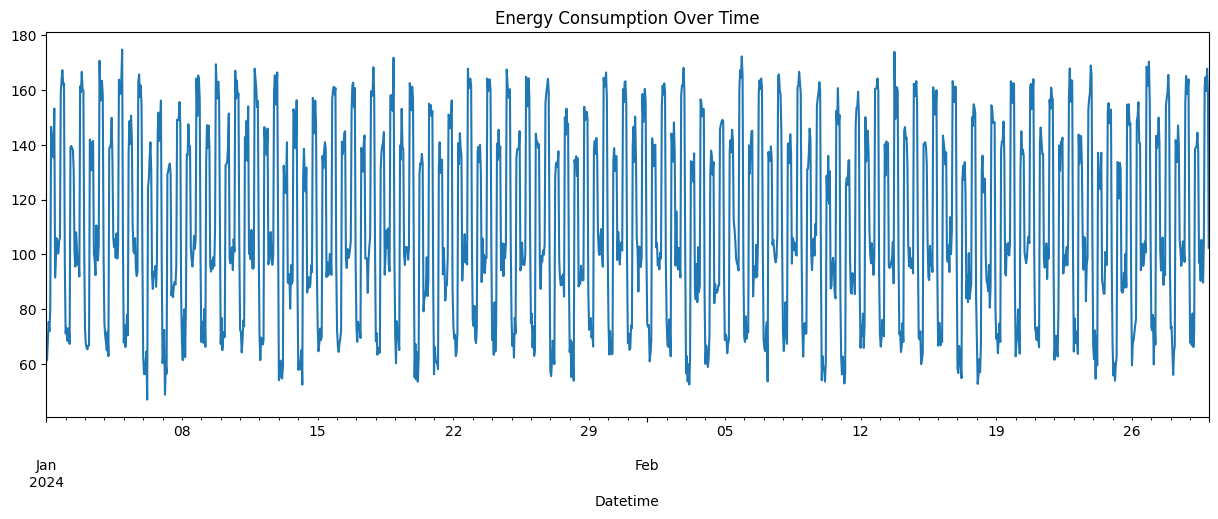

In [4]:
import matplotlib.pyplot as plt

data['Energy'].plot(figsize=(15,5), title="Energy Consumption Over Time")
plt.show()

In [5]:
data['hour'] = data.index.hour
data['day'] = data.index.dayofweek

data.head()

,Energy,hour,day
Datetime,,,
2024-01-01 00:00:00,70.465591,0,0
2024-01-01 01:00:00,61.283775,1,0
2024-01-01 02:00:00,67.862254,2,0
2024-01-01 03:00:00,75.249391,3,0
2024-01-01 04:00:00,71.944615,4,0


In [6]:
from sklearn.model_selection import train_test_split

X = data[['hour', 'day']]
y = data['Energy']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(hidden_layer_sizes=(64,64), max_iter=500)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


c:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [8]:
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 18.12503910124049


In [9]:
# Example: Wednesday (day=2), 2 PM (hour=14)
model.predict([[14, 2]])

c:\Users\Dell\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


array([112.57731893])

In [10]:
import joblib

joblib.dump(model, "energy_forecast_model.pkl")

print("Model saved!")

Model saved!


In [13]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    print("Running locally, no Drive mount needed")

Running locally, no Drive mount needed
